# Protocol v3 Redesign Notebook (Constrained Product Design)

This notebook implements and evaluates a redesigned v3 product under strict design constraints:

1. **Cover ratio is removed** (always full cover, i.e. `cover = 1`).
2. **Barrier is fixed by design to the CL lower bound** (`B = p_l`).
3. **Position width is fixed to `±7.5%`**.

## Research Questions (RQs)

1. What is a suitable pricing mechanism for a derivative that hedges LP concentrated-liquidity downside?
2. Which protocol **fee-split** configurations support joint LP/RT viability in comprehensive MC simulation?
3. How do alternative hedging strategies compare to the protocol derivative?
4. What is the breakeven LP fee-yield required for joint LP/RT viability, and how does LP profile compare under MC and backtest-style replay?


## 1) Product Formalization and Design Constraints

### 1.1 CL value and fixed product geometry

Let `S` be spot, `L` liquidity, and `(p_l, p_u)` the CL range. With fixed width `w = 7.5%`:

- `p_l = S_0(1-w)`
- `p_u = S_0(1+w)`

By design in this notebook:

- `cover = 1`
- `barrier B = p_l`

So depth is not an independent parameter anymore.

### 1.2 Corridor payoff (full cover)

The weekly payout is:

$$
\Pi(S_T)=\min\left(Cap,\max\left(0, V(S_0)-V(\max(S_T,B))\right)\right)
$$

with

$$
Cap = V(S_0)-V(B),\quad B=p_l
$$

Because cover is fixed to 1, no cover-scaling term appears.

### 1.3 Pricing mechanism used

We keep a transparent decomposition:

$$
Premium = \max\left(0, FV\cdot m_{vol} - y_{split}\cdot E[Fees]\right)
$$

where:

- `FV` is fair value from risk-neutral expectation of payoff,
- `m_vol` is a volatility loading (proxy for IV/RV style market loading),
- `y_split` is the protocol fee-yield split to RT,
- `E[Fees]` is expected LP fee income over the week.

This keeps one main governance degree of freedom: **yield split**.


## 2) Methodology Overview (Why This Is Sound)

### 2.1 Simulation regime

We use a **comprehensive Monte Carlo** built from historical return blocks (bootstrap weekly paths), which preserves empirical volatility clustering better than a naive iid Gaussian weekly draw.

### 2.2 Configuration experiment

Only `yield_split` is optimized/tested. We evaluate a broad grid, then highlight three representative points:

- low split,
- medium split,
- high split.

### 2.3 LP fee-yield scenarios

We explicitly stress three average LP fee-yield assumptions (daily):

- `0.15%` (`0.0015`),
- `0.23%` (`0.0023`),
- `0.35%` (`0.0035`).

### 2.4 Strategy comparison set

- Protocol corridor hedge (LP + RT economics)
- Fixed 50% perp hedge
- Dynamic perp hedge (rebalance each 1/10th of range move)
- Plain LP baseline

### 2.5 Viability criteria

Joint viability requires:

- LP mean weekly return > 0
- RT mean weekly return > 0

We also inspect LP tails (`p5`) and strategy breakeven metrics.


In [1]:
import os, json, math
import numpy as np
from scipy.special import ndtr
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.hermite import hermgauss
from urllib.request import urlopen
from urllib.parse import urlencode

from pathlib import Path

def resolve_data_dir():
    # Robust against different notebook working directories.
    # Prefer the real repo root by checking for lh-protocol-v3/protocol-src.
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        repo = parent / 'lh-protocol-v3'
        if (repo / 'protocol-src').exists():
            cand = repo / 'notebooks' / 'data'
            cand.mkdir(parents=True, exist_ok=True)
            return str(cand)
    # Fallback: local ./data
    fallback = here / 'data'
    fallback.mkdir(parents=True, exist_ok=True)
    return str(fallback)

DATA_DIR = resolve_data_dir()
os.makedirs(DATA_DIR, exist_ok=True)
rng = np.random.default_rng(42)

print('Environment ready.')


Environment ready.


In [2]:
# 3) Data loader (historical spot for bootstrap/backtest)

import os
import time
from urllib.request import Request, urlopen
import requests

# Methodology guardrail:
# - By default we require REAL market data for this notebook.
# - Synthetic data is allowed only if explicitly enabled for controlled stress tests.
USE_SYNTHETIC_DATA = False

# Prefer env var, fallback to the project key used in the other notebooks.
BIRDEYE_API_KEY = os.getenv('BIRDEYE_API_KEY', '').strip() or 'ed577a4a6a4f480fa659b4f18673e4b1'
SOL_MINT = 'So11111111111111111111111111111111111111112'

def fetch_birdeye_daily_sol(days=1150, chunk_days=90):
    """Fetch SOL daily OHLCV from Birdeye in chunks.

    Returns a DataFrame with columns: open_time (UTC timestamp), close (float).
    """
    if not BIRDEYE_API_KEY:
        raise RuntimeError('BIRDEYE_API_KEY is missing. Set env var or notebook default key.')

    now = int(time.time())
    start = now - int(days) * 24 * 3600
    rows = []

    url = 'https://public-api.birdeye.so/defi/ohlcv'
    headers = {'X-API-KEY': BIRDEYE_API_KEY, 'Accept': 'application/json', 'x-chain': 'solana'}

    t = start
    while t < now:
        t_to = min(t + int(chunk_days) * 24 * 3600, now)
        params = {
            'address': SOL_MINT,
            'type': '1D',
            'time_from': t,
            'time_to': t_to,
        }
        r = requests.get(url, params=params, headers=headers, timeout=20)
        r.raise_for_status()
        js = r.json()

        if not bool(js.get('success', False)):
            raise RuntimeError(f"Birdeye request failed for range [{t}, {t_to}]: {js}")

        items = js.get('data', {}).get('items', [])
        if not isinstance(items, list):
            raise RuntimeError('Unexpected Birdeye OHLCV schema: data.items is not a list')

        rows.extend(items)
        t = t_to

    if len(rows) == 0:
        raise RuntimeError('Birdeye returned empty OHLCV items')

    df = pd.DataFrame(rows)

    # schema-compatible parsing (v3/v4 notebooks sometimes use unixTime or startUnixTime)
    if 'unixTime' in df.columns:
        ts = pd.to_datetime(df['unixTime'], unit='s', utc=True)
    elif 'startUnixTime' in df.columns:
        ts = pd.to_datetime(df['startUnixTime'], unit='s', utc=True)
    else:
        raise RuntimeError(f"Unexpected Birdeye OHLCV columns: {list(df.columns)}")

    if 'c' in df.columns:
        close = pd.to_numeric(df['c'], errors='coerce')
    elif 'close' in df.columns:
        close = pd.to_numeric(df['close'], errors='coerce')
    else:
        raise RuntimeError(f"Unexpected Birdeye OHLCV close columns: {list(df.columns)}")

    out = pd.DataFrame({'open_time': ts, 'close': close}).dropna().sort_values('open_time').drop_duplicates('open_time').reset_index(drop=True)
    if len(out) < 365:
        raise RuntimeError(f"Birdeye returned too few daily points ({len(out)}).")
    return out

def fetch_binance_daily_sol(limit=1500):
    """Real-data fallback if Birdeye is temporarily unavailable."""
    base = 'https://api.binance.com/api/v3/klines'
    q = urlencode({'symbol': 'SOLUSDT', 'interval': '1d', 'limit': int(limit)})
    with urlopen(f"{base}?{q}", timeout=20) as r:
        rows = json.loads(r.read().decode('utf-8'))
    if not isinstance(rows, list) or len(rows) == 0:
        raise RuntimeError('Binance returned empty kline rows')
    df = pd.DataFrame(rows, columns=['open_time','open','high','low','close','volume','close_time','qv','n','tb','tq','ig'])
    df['open_time'] = pd.to_datetime(df['open_time'], unit='ms', utc=True)
    df['close'] = pd.to_numeric(df['close'], errors='coerce')
    out = df[['open_time','close']].dropna().sort_values('open_time').reset_index(drop=True)
    if len(out) < 365:
        raise RuntimeError(f"Binance returned too few daily points ({len(out)}).")
    return out

def build_synthetic_series(weeks=220, sigma=0.8):
    """Synthetic GBM-like daily path for explicit stress-test mode only."""
    dt = 1/52
    z = rng.standard_normal(weeks*7)
    rets = np.exp((-0.5*sigma**2)*dt/7 + sigma*np.sqrt(dt/7)*z)
    closes = np.empty(len(rets)+1)
    closes[0] = 100.0
    for i in range(len(rets)):
        closes[i+1] = closes[i]*rets[i]
    hist = pd.DataFrame({'open_time': pd.date_range(end=pd.Timestamp.utcnow(), periods=len(closes), freq='D', tz='UTC'), 'close': closes})
    return hist

try:
    hist = fetch_birdeye_daily_sol(days=1150, chunk_days=90)
    closes = hist['close'].to_numpy(float)
    src = 'birdeye_SOL_daily'
except Exception as e_birdeye:
    err_be = f"{type(e_birdeye).__name__}: {e_birdeye}"
    print(f"ERROR: failed to fetch real SOL daily data from Birdeye. Reason: {err_be}")

    # Real-data fallback path (still real market data, no synthetic).
    try:
        hist = fetch_binance_daily_sol(limit=1500)
        closes = hist['close'].to_numpy(float)
        src = f'binance_daily_fallback ({type(e_birdeye).__name__})'
        print('WARNING: using real-data Binance fallback because Birdeye fetch failed.')
    except Exception as e_binance:
        err_bn = f"{type(e_binance).__name__}: {e_binance}"
        print(f"ERROR: Binance real-data fallback also failed. Reason: {err_bn}")
        if USE_SYNTHETIC_DATA:
            print('WARNING: USE_SYNTHETIC_DATA=True -> using synthetic fallback by explicit choice.')
            hist = build_synthetic_series(weeks=220, sigma=0.8)
            closes = hist['close'].to_numpy(float)
            src = f'synthetic_fallback ({type(e_birdeye).__name__}, {type(e_binance).__name__})'
        else:
            raise RuntimeError('Real market data is required for this notebook. Birdeye and Binance fetch both failed. Set USE_SYNTHETIC_DATA=True only for explicit synthetic stress tests.') from e_binance

print('Source:', src)
print('Data points:', len(closes))



Source: birdeye_SOL_daily
Data points: 1150


In [3]:
# 4) Core CL and product math (fixed width, fixed barrier=lower bound)

WIDTH = 0.075
T_WEEK = 7/365
N_LIQ = 10_000.0
PROTOCOL_FEE_RATE = 0.015


def cl_value(S, L, p_l, p_u):
    S = np.asarray(S, float)
    sp, spl, spu = np.sqrt(np.clip(S, 1e-12, None)), np.sqrt(p_l), np.sqrt(p_u)
    below = S <= p_l
    above = S >= p_u
    a = np.where(below, L*(spu-spl)/(spl*spu), np.where(above, 0.0, L*(spu-sp)/(sp*spu)))
    b = np.where(below, 0.0, np.where(above, L*(spu-spl), L*(sp-spl)))
    return a*S + b


def make_pos(S0, lev=1.0):
    p_l, p_u = S0*(1-WIDTH), S0*(1+WIDTH)
    B = p_l  # by design
    L = N_LIQ*lev
    V0 = float(cl_value(np.array([S0]), L, p_l, p_u)[0])
    Vb = float(cl_value(np.array([B]), L, p_l, p_u)[0])
    cap = max(0.0, V0 - Vb)
    return {'p_l': p_l, 'p_u': p_u, 'B': B, 'L': L, 'V0': V0, 'cap': cap}


def corridor_payoff(S_T, S0, pos):
    V_eff = cl_value(np.maximum(S_T, pos['B']), pos['L'], pos['p_l'], pos['p_u'])
    raw = np.maximum(0.0, np.where(S_T >= S0, 0.0, pos['V0'] - V_eff))
    return np.minimum(pos['cap'], raw)


# Cached Gauss-Hermite nodes/weights (avoid recomputing inside MC loops)
QUAD_N = 48
QUAD_NODES, QUAD_WEIGHTS = hermgauss(QUAD_N)

def fv_quadrature(S0, sigma, pos, T=T_WEEK):
    S_T = S0*np.exp(-0.5*sigma**2*T + sigma*np.sqrt(T)*QUAD_NODES*np.sqrt(2))
    pay = corridor_payoff(S_T, S0, pos)
    return max(0.0, float(np.sum(QUAD_WEIGHTS*pay)/np.sqrt(np.pi)))


# IV/RV-style effective markup (v3/v4 compatible, but implemented as a cheap realized-vol proxy)
# In the full protocol, IV comes from options markets. In this redesign notebook (no option data fetching),
# we approximate the IV/RV loading with a regime-switching function driven by realized-vol level.
MARKUP_FLOOR = 0.99
IVRV_STRESS_THRESHOLD = 1.25

def iv_rv_regime_switching(s7, s30, stress):
    """Smooth IV/RV proxy: interpolate between low/high regimes.

    Uses ratio = s7 / s30 and maps it continuously into
    ivrv in [0.99, 1.12]. This avoids brittle behavior
    from binary regime thresholds.

    stress is accepted for API compatibility but not required for the mapping.
    """
    ratio = float(s7) / max(float(s30), 1e-9)
    IVRV_MIN = 0.99
    IVRV_MAX = 1.12
    RATIO_LOW = 0.90
    RATIO_HIGH = 1.30
    frac = np.clip((ratio - RATIO_LOW) / (RATIO_HIGH - RATIO_LOW), 0.0, 1.0)
    return float(IVRV_MIN + (IVRV_MAX - IVRV_MIN) * frac)

# Anchor realized volatility over the whole loaded history.
# This approximates the '30-day RV' reference used in the IV/RV logic.
lr_hist = np.diff(np.log(closes))
RV_ANCHOR = float(np.clip(np.std(lr_hist, ddof=1) * np.sqrt(365), 0.10, 3.0))

print('Core formulas ready. Width fixed at ±7.5%, barrier fixed at lower bound.')

Core formulas ready. Width fixed at ±7.5%, barrier fixed at lower bound.


In [4]:
# 5) Weekly path generation via historical block bootstrap


def build_weekly_blocks(prices, block_days=8):
    prices = np.asarray(prices, float)
    blocks = []
    for i in range(len(prices)-block_days+1):
        blocks.append(prices[i:i+block_days])
    return np.array(blocks)


def sample_weekly_path(blocks, n_weeks=52, rng_local=None):
    rng_eff = rng_local if rng_local is not None else rng
    idx = rng_eff.integers(0, len(blocks), size=n_weeks)
    sampled = blocks[idx]
    return sampled

blocks = build_weekly_blocks(closes, block_days=8)
print('Weekly blocks:', blocks.shape)

Weekly blocks: (1143, 8)


In [5]:
# 6) Strategy simulators

def simulate_protocol_mc(y_split, fee_day, n_paths=400, n_weeks=52, lev=1.2, tx_bps_open=2.0, tx_bps_settle=2.0):
    lp_w = []
    rt_w = []
    exec_cost_rate = (tx_bps_open + tx_bps_settle)/10_000

    yq = round(float(y_split), 3)
    fdq = round(float(fee_day), 7)
    seed = int((yq*1e6 + fdq*1e6)*1000) % 2**32
    rng_local = np.random.default_rng(seed)


    for _ in range(n_paths):
        rt_cap = 2_000_000.0
        idle_yield_week = (1+0.002)**7 - 1
        blocks_s = sample_weekly_path(blocks, n_weeks=n_weeks, rng_local=rng_local)

        for wk in blocks_s:
            S0, ST = float(wk[0]), float(wk[-1])
            lr = np.diff(np.log(wk))
            rv30_proxy = float(np.clip(np.std(lr, ddof=1)*np.sqrt(365), 0.25, 1.8))
            pos = make_pos(S0, lev=lev)
            if pos['cap'] <= 1e-9:
                continue

            fv = fv_quadrature(S0, rv30_proxy, pos)
            # IV/RV-style effective markup using realized-vol regime approximation
            s7 = rv30_proxy
            s30 = RV_ANCHOR
            stress_flag = (s7 / max(s30, 1e-9) > 1.25)
            ivrv = iv_rv_regime_switching(s7, s30, stress_flag)
            m_vol = max(MARKUP_FLOOR, ivrv)
            # Expected in-range fraction under a lognormal model (no look-ahead for fee discount)
            # With p_l = S0*(1-WIDTH) and p_u = S0*(1+WIDTH), bounds in log-space are constants.
            t_days = np.arange(1, 8) / 365.0
            sigma = max(rv30_proxy, 1e-9)
            mu = -0.5 * (sigma**2) * t_days
            sd = sigma * np.sqrt(t_days)
            a_log = np.log(1.0 - WIDTH)
            b_log = np.log(1.0 + WIDTH)
            p_in = ndtr((b_log - mu) / sd) - ndtr((a_log - mu) / sd)
            exp_in_range_frac = float(np.mean(p_in))

            exp_fees = pos['V0'] * fee_day * 7
            premium = max(0.0, fv*m_vol - y_split*exp_fees)

            # realized fees: keep slight randomness around assumed mean
            realized_fee_day = float(np.clip(rng_local.normal(fee_day,0.0007),0.0003,0.02))
            in_range_frac_real = float(np.mean((wk[1:] >= pos['p_l']) & (wk[1:] <= pos['p_u'])))
            fees = pos['V0'] * realized_fee_day * 7

            payoff = float(corridor_payoff(np.array([ST]), S0, pos)[0])
            Vend = float(cl_value(np.array([ST]), pos['L'], pos['p_l'], pos['p_u'])[0])
            protocol_exec_cost = exec_cost_rate * pos['V0']

            lp_pnl = (Vend - pos['V0']) + fees*(1-y_split) + payoff - premium - protocol_exec_cost
            rt_pnl = premium*(1-PROTOCOL_FEE_RATE) + fees*y_split - payoff

            lp_ret = lp_pnl/max(pos['V0'],1e-9)
            rt_ret = rt_pnl/max(rt_cap,1e-9)
            rt_cap *= (1 + rt_ret + idle_yield_week)

            lp_w.append(lp_ret)
            rt_w.append(rt_ret)

    return np.array(lp_w, float), np.array(rt_w, float)


def cl_amount_sol(S, L, p_l, p_u):
    sp, spl, spu = np.sqrt(max(S,1e-12)), np.sqrt(p_l), np.sqrt(p_u)
    if S <= p_l:
        return L*(spu-spl)/(spl*spu)
    if S >= p_u:
        return 0.0
    return L*(spu-sp)/(sp*spu)


def simulate_perp_mc(mode='fixed', fee_day=0.0023, n_paths=400, n_weeks=52, lev=1.2, tx_cost_bps=2.0, funding_bps_day=1.0):
    out = []
    tx_cost = tx_cost_bps/10_000
    funding = funding_bps_day/10_000

    fdq = round(float(fee_day), 7)
    modeflag = 0 if mode=='fixed' else 1
    seed = int((fdq*1e6)*1000 + modeflag*999) % 2**32
    rng_local = np.random.default_rng(seed)

    for _ in range(n_paths):
        blocks_s = sample_weekly_path(blocks, n_weeks=n_weeks, rng_local=rng_local)
        for wk in blocks_s:
            S0, ST = float(wk[0]), float(wk[-1])
            path = wk
            pos = make_pos(S0, lev=lev)
            a0 = cl_amount_sol(S0, pos['L'], pos['p_l'], pos['p_u'])
            hedge_qty = 0.5*a0
            decile = (pos['p_u']-pos['p_l'])/10
            anchor = S0

            fee_income = 0.0
            perp_pnl = 0.0
            funding_cf = 0.0
            tcost = abs(hedge_qty)*S0*tx_cost

            realized_fee_day = float(np.clip(rng_local.normal(fee_day,0.0007),0.0003,0.02))

            for d in range(1,len(path)):
                s_prev, s_cur = float(path[d-1]), float(path[d])
                V_prev = float(cl_value(np.array([s_prev]), pos['L'], pos['p_l'], pos['p_u'])[0])
                in_range = (s_prev >= pos['p_l']) and (s_prev <= pos['p_u'])
                fee_income += pos['V0'] * realized_fee_day * (0.95 if in_range else 0.05)
                perp_pnl += -hedge_qty*(s_cur-s_prev)
                funding_cf += abs(hedge_qty*s_prev)*funding

                if mode=='dynamic' and abs(s_cur-anchor)>=decile:
                    drop_frac = max(0.0,(S0-s_cur)/max(pos['p_u']-pos['p_l'],1e-9))
                    target_ratio = float(np.clip(0.5 + drop_frac, 0.1, 1.0))
                    a_cur = cl_amount_sol(s_cur, pos['L'], pos['p_l'], pos['p_u'])
                    target_qty = target_ratio*a_cur
                    dq = target_qty-hedge_qty
                    tcost += abs(dq)*s_cur*tx_cost
                    hedge_qty = target_qty
                    anchor = s_cur

            tcost += abs(hedge_qty)*ST*tx_cost
            Vend = float(cl_value(np.array([ST]), pos['L'], pos['p_l'], pos['p_u'])[0])
            lp_pnl = (Vend-pos['V0']) + fee_income + perp_pnl + funding_cf - tcost
            out.append(lp_pnl/max(pos['V0'],1e-9))

    return np.array(out, float)


def simulate_plain_lp_mc(fee_day=0.0023, n_paths=400, n_weeks=52, lev=1.2):
    out=[]
    fdq = round(float(fee_day), 7)
    seed = int((fdq*1e6)*1000) % 2**32
    rng_local = np.random.default_rng(seed)
    for _ in range(n_paths):
        blocks_s = sample_weekly_path(blocks, n_weeks=n_weeks, rng_local=rng_local)
        for wk in blocks_s:
            S0, ST = float(wk[0]), float(wk[-1])
            pos = make_pos(S0, lev=lev)
            realized_fee_day = float(np.clip(rng_local.normal(fee_day,0.0007),0.0003,0.02))
            in_range_frac_real = float(np.mean((wk[1:] >= pos['p_l']) & (wk[1:] <= pos['p_u'])))
            fees = pos['V0']*realized_fee_day*7*(in_range_frac_real*0.95+0.05)
            Vend = float(cl_value(np.array([ST]), pos['L'], pos['p_l'], pos['p_u'])[0])
            out.append(((Vend-pos['V0'])+fees)/max(pos['V0'],1e-9))
    return np.array(out,float)


print('Strategy simulators ready.')

Strategy simulators ready.


In [6]:
# 7) RQ2: optimize only yield split via comprehensive MC

y_split_grid = np.round(np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]), 3)
fee_day_scenarios = {
    'low_fee_0.15pct_day': 0.0015,
    'mid_fee_0.23pct_day': 0.0023,
    'high_fee_0.35pct_day': 0.0035,
}

rows=[]
for scen, fee_day in fee_day_scenarios.items():
    for ys in y_split_grid:
        lp, rt = simulate_protocol_mc(y_split=ys, fee_day=fee_day, n_paths=200, n_weeks=28)
        if len(lp)==0 or len(rt)==0:
            continue
        rows.append({
            'scenario': scen,
            'yield_split': ys,
            'lp_mean_%': 100*float(np.mean(lp)),
            'lp_p5_%': 100*float(np.quantile(lp,0.05)),
            'rt_mean_%': 100*float(np.mean(rt)),
            'rt_p5_%': 100*float(np.quantile(rt,0.05)),
            'joint_viable': bool((np.mean(lp)>0) and (np.mean(rt)>0)),
        })

opt_df = pd.DataFrame(rows)
opt_df['score'] = opt_df['lp_mean_%'] + 1.1*opt_df['rt_mean_%'] + 0.3*opt_df['rt_p5_%']
opt_df.to_csv(os.path.join(DATA_DIR,'v3_redesign_yield_split_grid.csv'), index=False)

print('Grid results saved:', os.path.join(DATA_DIR,'v3_redesign_yield_split_grid.csv'))
print('Total rows:', len(opt_df))
print('Joint viable rows:', int(opt_df['joint_viable'].sum()))
opt_df.sort_values(['joint_viable','score'], ascending=[False,False]).head(12)

Grid results saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data/v3_redesign_yield_split_grid.csv
Total rows: 21
Joint viable rows: 0


,scenario,yield_split,lp_mean_%,lp_p5_%,rt_mean_%,rt_p5_%,joint_viable,score
19,high_fee_0.35pct_day,0.30,-0.009558,-7.654164,0.000322,-0.018655,False,-0.014801
20,high_fee_0.35pct_day,0.40,-0.034976,-7.939922,0.000438,-0.018600,False,-0.040074
18,high_fee_0.35pct_day,0.25,-0.058012,-8.194386,0.000397,-0.018604,False,-0.063157
14,high_fee_0.35pct_day,0.05,-0.071483,-8.196532,-0.000053,-0.018849,False,-0.077196
17,high_fee_0.35pct_day,0.20,-0.086803,-8.336835,0.000073,-0.018831,False,-0.092373
15,high_fee_0.35pct_day,0.10,-0.088027,-8.106245,0.000294,-0.018670,False,-0.093304
16,high_fee_0.35pct_day,0.15,-0.156429,-8.366810,0.000055,-0.018704,False,-0.161979
7,mid_fee_0.23pct_day,0.05,-0.888573,-9.199133,0.000356,-0.018592,False,-0.893759
13,mid_fee_0.23pct_day,0.40,-0.904219,-9.054947,0.000244,-0.018731,False,-0.909570
12,mid_fee_0.23pct_day,0.30,-0.906355,-8.921947,0.000230,-0.018322,False,-0.911598


In [7]:
# 8) Choose representative low/medium/high yield-split configs from viable region

rep_rows=[]
for scen in fee_day_scenarios:
    d = opt_df[(opt_df['scenario']==scen) & (opt_df['joint_viable'])].sort_values('yield_split')
    if len(d)==0:
        d = opt_df[opt_df['scenario']==scen].sort_values('score', ascending=False)
    if len(d)==0:
        continue
    idxs = [0, len(d)//2, len(d)-1]
    labels=['low','medium','high']
    for lab,ix in zip(labels,idxs):
        r=d.iloc[ix]
        rep_rows.append({
            'scenario': scen,
            'representative_level': lab,
            'yield_split': float(r['yield_split']),
            'lp_mean_%': float(r['lp_mean_%']),
            'rt_mean_%': float(r['rt_mean_%']),
            'joint_viable': bool(r['joint_viable'])
        })

rep = pd.DataFrame(rep_rows)
rep.to_csv(os.path.join(DATA_DIR,'v3_redesign_representative_configs.csv'), index=False)
print('Saved:', os.path.join(DATA_DIR,'v3_redesign_representative_configs.csv'))
rep

Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data/v3_redesign_representative_configs.csv


,scenario,representative_level,yield_split,lp_mean_%,rt_mean_%,joint_viable
0,low_fee_0.15pct_day,low,0.15,-1.362031,0.000294,False
1,low_fee_0.15pct_day,medium,0.25,-1.430413,0.000314,False
2,low_fee_0.15pct_day,high,0.40,-1.535616,0.000108,False
3,mid_fee_0.23pct_day,low,0.05,-0.888573,0.000356,False
4,mid_fee_0.23pct_day,medium,0.25,-0.914364,0.000169,False
5,mid_fee_0.23pct_day,high,0.20,-0.988951,0.000035,False
6,high_fee_0.35pct_day,low,0.30,-0.009558,0.000322,False
7,high_fee_0.35pct_day,medium,0.05,-0.071483,-0.000053,False
8,high_fee_0.35pct_day,high,0.15,-0.156429,0.000055,False


In [8]:
# 9) RQ3 & RQ4: strategy comparison + breakeven by scenario

def breakeven_bps_weekly(ret_series, V0=1.0):
    # with normalized denominator this is 10k * mean return
    return 10_000 * float(np.mean(ret_series))

comp_rows=[]
grid_df = pd.read_csv(os.path.join(DATA_DIR,'v3_redesign_yield_split_grid.csv'))
rep = pd.read_csv(os.path.join(DATA_DIR,'v3_redesign_representative_configs.csv'))
for _,r in rep.iterrows():
    scen = r['scenario']
    fee_day = fee_day_scenarios[scen]
    ys = float(r['yield_split'])

    grid_row = grid_df[(grid_df['scenario']==scen) & (np.isclose(grid_df['yield_split'], ys, atol=1e-9))].iloc[0]
    lp_f = simulate_perp_mc(mode='fixed', fee_day=fee_day, n_paths=80, n_weeks=28)
    lp_d = simulate_perp_mc(mode='dynamic', fee_day=fee_day, n_paths=80, n_weeks=28)
    lp_plain = simulate_plain_lp_mc(fee_day=fee_day, n_paths=80, n_weeks=28)

    comp_rows += [
        {'scenario':scen,'rep_level':r['representative_level'],'strategy':'protocol_lp','mean_%':float(grid_row['lp_mean_%']),'p5_%':float(grid_row['lp_p5_%']),'breakeven_bps_week':100.0*float(grid_row['lp_mean_%']),'rt_mean_%':float(grid_row['rt_mean_%'])},
        {'scenario':scen,'rep_level':r['representative_level'],'strategy':'perp_fixed_lp','mean_%':100*np.mean(lp_f),'p5_%':100*np.quantile(lp_f,0.05),'breakeven_bps_week':breakeven_bps_weekly(lp_f),'rt_mean_%':np.nan},
        {'scenario':scen,'rep_level':r['representative_level'],'strategy':'perp_dynamic_lp','mean_%':100*np.mean(lp_d),'p5_%':100*np.quantile(lp_d,0.05),'breakeven_bps_week':breakeven_bps_weekly(lp_d),'rt_mean_%':np.nan},
        {'scenario':scen,'rep_level':r['representative_level'],'strategy':'plain_lp','mean_%':100*np.mean(lp_plain),'p5_%':100*np.quantile(lp_plain,0.05),'breakeven_bps_week':breakeven_bps_weekly(lp_plain),'rt_mean_%':np.nan},
    ]

comp = pd.DataFrame(comp_rows)
comp.to_csv(os.path.join(DATA_DIR,'v3_redesign_strategy_comparison_mc.csv'), index=False)
print('Saved:', os.path.join(DATA_DIR,'v3_redesign_strategy_comparison_mc.csv'))
comp.head(16)

Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data/v3_redesign_strategy_comparison_mc.csv


,scenario,rep_level,strategy,mean_%,p5_%,breakeven_bps_week,rt_mean_%
0,low_fee_0.15pct_day,low,protocol_lp,-1.362031,-8.955526,-136.203125,0.000294
1,low_fee_0.15pct_day,low,perp_fixed_lp,-1.867421,-9.577252,-186.742084,NaN
2,low_fee_0.15pct_day,low,perp_dynamic_lp,-1.957381,-6.987085,-195.738141,NaN
3,low_fee_0.15pct_day,low,plain_lp,-1.578911,-13.163873,-157.891096,NaN
4,low_fee_0.15pct_day,medium,protocol_lp,-1.430413,-9.352480,-143.041268,0.000314
5,low_fee_0.15pct_day,medium,perp_fixed_lp,-1.867421,-9.577252,-186.742084,NaN
6,low_fee_0.15pct_day,medium,perp_dynamic_lp,-1.957381,-6.987085,-195.738141,NaN
7,low_fee_0.15pct_day,medium,plain_lp,-1.578911,-13.163873,-157.891096,NaN
8,low_fee_0.15pct_day,high,protocol_lp,-1.535616,-9.871910,-153.561617,0.000108
9,low_fee_0.15pct_day,high,perp_fixed_lp,-1.867421,-9.577252,-186.742084,NaN


In [9]:
# 10) Breakeven LP fee-yield needed for joint viability (protocol)

fee_grid = np.round(np.linspace(0.0012, 0.0048, 7), 6)
be_rows=[]

for ys in sorted(rep['yield_split'].unique()):
    feasible_fee = None
    for fd in fee_grid:
        lp, rt = simulate_protocol_mc(y_split=float(ys), fee_day=float(fd), n_paths=70, n_weeks=28)
        joint = (np.mean(lp)>0) and (np.mean(rt)>0)
        be_rows.append({
            'yield_split': float(ys),
            'fee_day': float(fd),
            'lp_mean_%': 100*np.mean(lp),
            'rt_mean_%': 100*np.mean(rt),
            'joint_viable': bool(joint),
        })
        if feasible_fee is None and joint:
            feasible_fee = float(fd)

be_df = pd.DataFrame(be_rows)
be_df.to_csv(os.path.join(DATA_DIR,'v3_redesign_joint_viability_fee_breakeven.csv'), index=False)

summary = []
for ys in sorted(rep['yield_split'].unique()):
    d = be_df[be_df['yield_split']==ys]
    ok = d[d['joint_viable']]
    summary.append({
        'yield_split': ys,
        'breakeven_fee_day_for_joint_viability': float(ok['fee_day'].min()) if len(ok) else np.nan,
        'max_lp_mean_%': float(d['lp_mean_%'].max()),
        'max_rt_mean_%': float(d['rt_mean_%'].max()),
    })

be_sum = pd.DataFrame(summary)
print('Saved:', os.path.join(DATA_DIR,'v3_redesign_joint_viability_fee_breakeven.csv'))
be_sum

Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data/v3_redesign_joint_viability_fee_breakeven.csv


,yield_split,breakeven_fee_day_for_joint_viability,max_lp_mean_%,max_rt_mean_%
0,0.05,0.0036,0.826469,0.000406
1,0.15,0.0036,0.830016,0.000356
2,0.20,0.0042,0.853403,0.000419
3,0.25,0.0036,0.865320,0.000379
4,0.30,0.0036,0.879221,0.000590
5,0.40,0.0036,1.084466,0.000660


Saved: /home/sowelo/Scrivania/LiquidityHedge/lh-protocol-v3/notebooks/data/v3_redesign_summary_plots.png


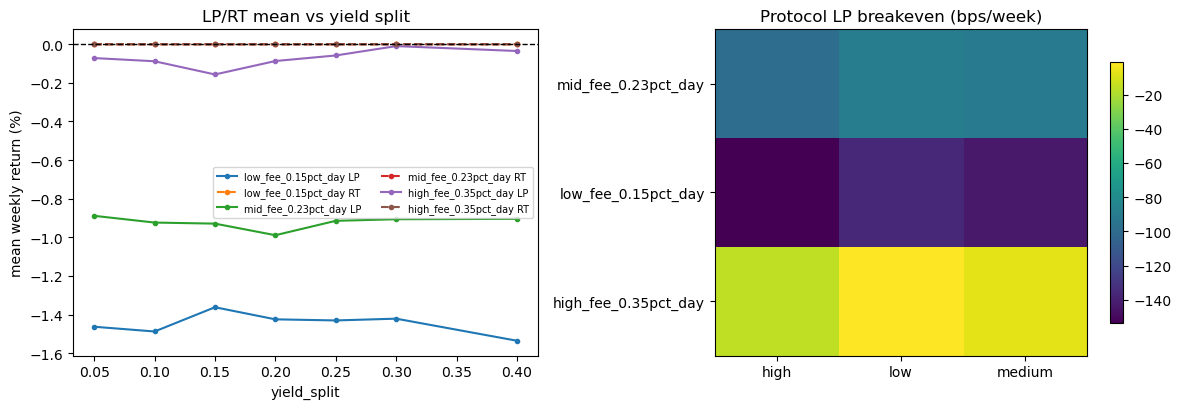

In [10]:
# 11) Compact plots

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

for scen in fee_day_scenarios:
    d = opt_df[opt_df['scenario']==scen].sort_values('yield_split')
    ax[0].plot(d['yield_split'], d['lp_mean_%'], '-o', ms=3, label=f'{scen} LP')
    ax[0].plot(d['yield_split'], d['rt_mean_%'], '--o', ms=3, label=f'{scen} RT')
ax[0].axhline(0, ls='--', c='black', lw=1)
ax[0].set_title('LP/RT mean vs yield split')
ax[0].set_xlabel('yield_split')
ax[0].set_ylabel('mean weekly return (%)')
ax[0].legend(fontsize=7, ncol=2)

pivot = comp[comp['strategy']=='protocol_lp'].pivot_table(index='scenario', columns='rep_level', values='breakeven_bps_week', aggfunc='mean')
im = ax[1].imshow(pivot.values, origin='lower', aspect='auto', cmap='viridis')
ax[1].set_title('Protocol LP breakeven (bps/week)')
ax[1].set_xticks(range(len(pivot.columns))); ax[1].set_xticklabels(pivot.columns)
ax[1].set_yticks(range(len(pivot.index))); ax[1].set_yticklabels(pivot.index)
fig.colorbar(im, ax=ax[1], shrink=0.8)

plt.tight_layout()
fig.savefig(os.path.join(DATA_DIR,'v3_redesign_summary_plots.png'), dpi=150)
print('Saved:', os.path.join(DATA_DIR,'v3_redesign_summary_plots.png'))

## 12) Interpretation Template (for Decision)

Use the saved tables to answer the RQs rigorously:

- `v3_redesign_yield_split_grid.csv`: identifies viable fee-split region under each LP fee-yield scenario.
- `v3_redesign_representative_configs.csv`: low/medium/high representative points from viable candidates.
- `v3_redesign_strategy_comparison_mc.csv`: protocol vs alternatives (LP profile + breakeven).
- `v3_redesign_joint_viability_fee_breakeven.csv`: minimum LP fee-yield needed for joint LP/RT viability at each split.

Decision logic:

1. Keep only yield splits that are jointly viable in at least the medium-fee scenario.
2. Prefer points where protocol LP dominates perp alternatives on mean and breakeven with acceptable tail (`p5`).
3. Reject points needing implausibly high LP fee-yield to sustain RT viability.
4. Launch with one representative medium split and monitor RT drift/tails for governance retuning.
